# Scale 불량 데이터 전처리 & EDA

후판 압연공정 Scale 불량 데이터(`SCALE불량.csv`, 1,000행)를 정제하고, 모델링에 쓸 파생 피처를 만든다.

**사전 확인된 핵심 신호**
1. `hsb`(Hot Scale Breaker) 미적용 47건은 전량 불량(100%) — 강력한 단일 신호
2. `rolling_temp == 0` 인 6건은 물리적으로 불가능한 값 → 센서 미기록으로 보고 결측 처리
3. `rolling_temp >= 1000` 구간에서 불량률이 급증 (완만한 상관관계가 아니라 계단식 임계효과)
4. `fur_soak_temp - rolling_temp`(온도 낙차)가 양품/불량 간 뚜렷한 차이를 보임
5. `rolling_date`가 존재 → 랜덤 분할이 아닌 **시간 기준 분할**이 필요

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 50)

REPO_ROOT = Path.cwd().parent
RAW_PATH = REPO_ROOT / "data" / "raw" / "SCALE불량.csv"
OUT_PATH = REPO_ROOT / "data" / "processed" / "scale_processed.csv"
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

## 1. 데이터 로드

In [2]:
def load_raw(path: Path = RAW_PATH) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="cp949")
    df["rolling_date"] = pd.to_datetime(df["rolling_date"], format="%d%b%Y:%H:%M:%S")
    return df

df = load_raw()
print(f"원본 데이터: {df.shape}")
df.head()

원본 데이터: (1000, 21)


,plate_no,rolling_date,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,fur_no,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group
0,PLT_1001,2023-01-03 07:07:53,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,1열,1144,116,1133,59,259,TMCP(온도제어),934,8,1조
1,PLT_1002,2023-01-03 07:21:22,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,2열,1144,122,1135,53,238,TMCP(온도제어),937,8,1조
2,PLT_1003,2023-01-03 07:31:15,양품,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,1열,1129,116,1121,55,258,TMCP(온도제어),889,8,1조
3,PLT_1004,2023-01-03 07:41:01,양품,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,2열,1152,125,1127,68,266,TMCP(온도제어),885,8,1조
4,PLT_1005,2023-01-03 07:52:40,양품,BV-EH36-TM,프랑스,T,38,3100,13300,적용,3호기,1열,1140,134,1128,48,246,TMCP(온도제어),873,8,1조


In [3]:
df["scale"].value_counts(normalize=True).rename("비율").to_frame()

,비율
scale,
양품,0.69
불량,0.31


## 2. 결측치 / 이상치 처리

`rolling_temp<=0`(물리적으로 불가능)은 결측으로 간주해 같은 조건(강종×압연방식) 그룹의 중앙값으로 대치한다. IQR 밖 값들은 **제거하지 않는다** — 이 도메인에서는 극단값이 오히려 핵심 신호(1000℃ 임계효과)일 수 있기 때문이다.

In [4]:
def clean_missing_and_outliers(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["rolling_temp_was_missing"] = (df["rolling_temp"] <= 0).astype(int)
    n_bad_zero = df["rolling_temp_was_missing"].sum()
    df.loc[df["rolling_temp"] <= 0, "rolling_temp"] = np.nan

    group_median = df.groupby(["steel_kind", "rolling_method"])["rolling_temp"].transform("median")
    df["rolling_temp"] = df["rolling_temp"].fillna(group_median)
    df["rolling_temp"] = df["rolling_temp"].fillna(df["rolling_temp"].median())
    print(f"[클린징] rolling_temp<=0 -> 결측 처리 후 그룹 중앙값 대치: {n_bad_zero}건")

    num_cols = ["pt_thick", "pt_width", "pt_length", "fur_heat_temp", "fur_heat_time",
                "fur_soak_temp", "fur_soak_time", "fur_total_time", "rolling_temp", "descaling_count"]
    cat_cols = ["spec_long", "spec_country", "steel_kind", "hsb",
                "fur_no", "fur_input_row", "rolling_method", "work_group"]

    for c in num_cols:
        n_na = df[c].isna().sum()
        if n_na > 0:
            df[c] = df[c].fillna(df[c].median())
            print(f"[클린징] {c}: 결측 {n_na}건 -> 중앙값 대치")

    for c in cat_cols:
        n_na = df[c].isna().sum()
        if n_na > 0:
            df[c] = df[c].fillna(df[c].mode().iloc[0])
            print(f"[클린징] {c}: 결측 {n_na}건 -> 최빈값 대치")

    for c in ["fur_heat_temp", "fur_soak_temp", "rolling_temp"]:
        q1, q3 = df[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((df[c] < lo) | (df[c] > hi)).sum()
        print(f"[이상치 점검] {c}: IQR 범위[{lo:.1f}, {hi:.1f}] 밖 {n_out}건 (제거하지 않음)")

    return df

df = clean_missing_and_outliers(df)

[클린징] rolling_temp<=0 -> 결측 처리 후 그룹 중앙값 대치: 6건
[이상치 점검] fur_heat_temp: IQR 범위[1090.5, 1222.5] 밖 0건 (제거하지 않음)
[이상치 점검] fur_soak_temp: IQR 범위[1093.4, 1206.4] 밖 0건 (제거하지 않음)
[이상치 점검] rolling_temp: IQR 범위[748.5, 1136.5] 밖 5건 (제거하지 않음)


## 3. 핵심 신호 시각화

표로만 보던 세 가지 핵심 발견을 그래프로 확인한다.

C:\Users\aidan\AppData\Local\Temp\ipykernel_8864\2323023724.py:9: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aidan\AppData\Local\Temp\ipykernel_8864\2323023724.py:9: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aidan\AppData\Local\Temp\ipykernel_8864\2323023724.py:9: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aidan\AppData\Local\Temp\ipykernel_8864\2323023724.py:9: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aidan\AppData\Local\Temp\ipykernel_8864\2323023724.py:9: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aidan\AppData\Local\Temp\ipykernel_8864\2323023724.py:9: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtool

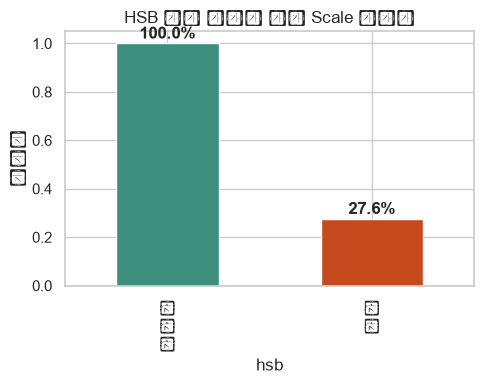

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
rate = df.groupby("hsb")["scale"].apply(lambda s: (s == "불량").mean())
rate.plot.bar(ax=ax, color=["#3E8E7E", "#C74A1E"])
ax.set_ylabel("불량률")
ax.set_title("HSB 적용 여부에 따른 Scale 불량률")
ax.set_ylim(0, 1.05)
for i, v in enumerate(rate):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\aidan\AppData\Local\Temp\ipykernel_8864\2984862700.py:7: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aidan\AppData\Local\Temp\ipykernel_8864\2984862700.py:7: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aidan\AppData\Local\Temp\ipykernel_8864\2984862700.py:7: UserWarning: Glyph 50517 (\N{HANGUL SYLLABLE AB}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aidan\AppData\Local\Temp\ipykernel_8864\2984862700.py:7: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aidan\AppData\Local\Temp\ipykernel_8864\2984862700.py:7: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aidan\AppData\Local\Temp\ipykernel_8864\2984862700.py:7: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Use

C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50517 (\N{HANGUL SYLLABLE AB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools

C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8451 (\N{DEGREE CELSIUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


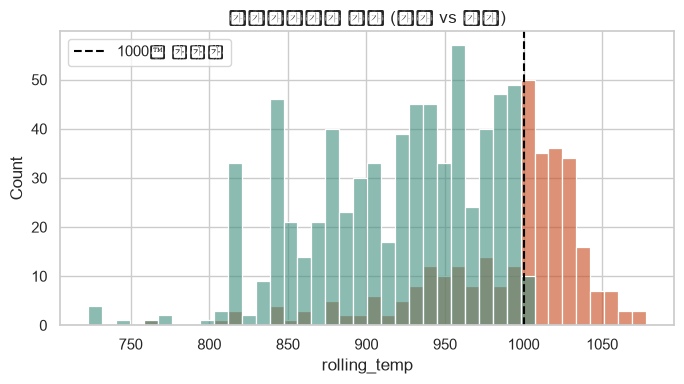

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df, x="rolling_temp", hue="scale", bins=40, ax=ax,
             palette={"양품": "#3E8E7E", "불량": "#C74A1E"}, alpha=0.6)
ax.axvline(1000, color="black", linestyle="--", linewidth=1.5, label="1000℃ 임계선")
ax.set_title("사상압연온도 분포 (양품 vs 불량)")
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\aidan\AppData\Local\Temp\ipykernel_8864\2245983443.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["scale"], y=temp_drop, ax=ax,


C:\Users\aidan\AppData\Local\Temp\ipykernel_8864\2245983443.py:7: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aidan\AppData\Local\Temp\ipykernel_8864\2245983443.py:7: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aidan\AppData\Local\Temp\ipykernel_8864\2245983443.py:7: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aidan\AppData\Local\Temp\ipykernel_8864\2245983443.py:7: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aidan\AppData\Local\Temp\ipykernel_8864\2245983443.py:7: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aidan\AppData\Local\Temp\ipykernel_8864\2245983443.py:7: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  plt.tight_layout()
C:\

C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aidan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabto

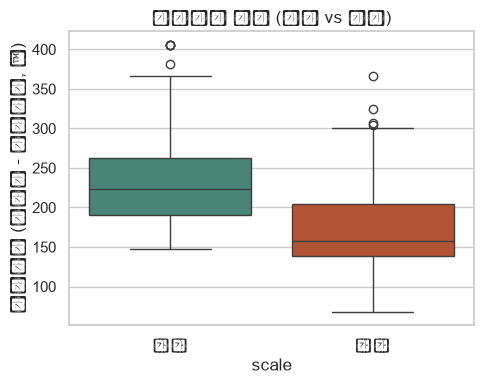

,평균 온도낙차(℃)
scale,
불량,170.651613
양품,228.982609


In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
temp_drop = df["fur_soak_temp"] - df["rolling_temp"]
sns.boxplot(x=df["scale"], y=temp_drop, ax=ax,
            palette={"양품": "#3E8E7E", "불량": "#C74A1E"})
ax.set_ylabel("온도낙차 (균열대 - 사상압연, ℃)")
ax.set_title("온도낙차 분포 (양품 vs 불량)")
plt.tight_layout()
plt.show()

temp_drop.groupby(df["scale"]).mean().rename("평균 온도낙차(℃)").to_frame()

## 4. 파생 변수 (피처 엔지니어링)

In [8]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["hsb_applied"] = (df["hsb"] == "적용").astype(int)
    df["temp_drop"] = df["fur_soak_temp"] - df["rolling_temp"]
    df["heat_soak_gap"] = df["fur_heat_temp"] - df["fur_soak_temp"]
    df["rolling_temp_over_1000"] = (df["rolling_temp"] >= 1000).astype(int)
    df["rolling_temp_bin"] = pd.cut(
        df["rolling_temp"], bins=[0, 800, 850, 900, 950, 1000, np.inf],
        labels=["<800", "800-850", "850-900", "900-950", "950-1000", ">=1000"],
    )
    df["hsb_x_rolling_temp"] = df["hsb_applied"] * df["rolling_temp"]
    df["hsb_x_over1000"] = df["hsb_applied"] * df["rolling_temp_over_1000"]
    df["hsb_x_descaling"] = df["hsb_applied"] * df["descaling_count"]
    # 라벨에 '<','[',']' 미사용: XGBoost/LightGBM이 피처명에 이 문자를 허용하지 않음
    df["thick_bucket"] = pd.cut(
        df["pt_thick"], bins=[0, 20, 40, 60, np.inf],
        labels=["박(20미만)", "중(20-40)", "후(40-60)", "극후(60이상)"],
    )
    df["cooling_rate_proxy"] = df["temp_drop"] / df["fur_total_time"].replace(0, np.nan)
    df["cooling_rate_proxy"] = df["cooling_rate_proxy"].fillna(df["cooling_rate_proxy"].median())
    df["descaling_is_odd"] = (df["descaling_count"] % 2 == 1).astype(int)
    df["rolling_hour"] = df["rolling_date"].dt.hour
    df["rolling_dow"] = df["rolling_date"].dt.dayofweek
    df["target"] = (df["scale"] == "불량").astype(int)
    return df

df = engineer_features(df)
df[["temp_drop", "heat_soak_gap", "rolling_temp_over_1000", "thick_bucket", "target"]].head()

,temp_drop,heat_soak_gap,rolling_temp_over_1000,thick_bucket,target
0,199.0,11,0,중(20-40),0
1,198.0,9,0,중(20-40),0
2,232.0,8,0,중(20-40),0
3,242.0,25,0,중(20-40),0
4,255.0,12,0,중(20-40),0


## 5. 저장

In [9]:
df.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")
print(f"[저장] {OUT_PATH} ({df.shape})")

[저장] C:\Users\aidan\OneDrive\바탕 화면\종합실습\종합실습2\data\processed\scale_processed.csv ((1000, 36))


## 6. 시간 기준 분할

`rolling_date` 순으로 정렬해 앞 70%를 train, 다음 15%를 valid, 마지막 15%를 test로 쓴다. 실제 조업 환경처럼 '과거로 미래를 예측'하는 상황을 재현해, 랜덤 분할 대비 낙관적으로 부풀려진 성능 추정을 방지한다.

In [10]:
def time_based_split(df: pd.DataFrame, valid_size: float = 0.15, test_size: float = 0.15):
    df_sorted = df.sort_values("rolling_date").reset_index(drop=True)
    n = len(df_sorted)
    n_test = int(n * test_size)
    n_valid = int(n * valid_size)
    n_train = n - n_valid - n_test
    train = df_sorted.iloc[:n_train]
    valid = df_sorted.iloc[n_train:n_train + n_valid]
    test = df_sorted.iloc[n_train + n_valid:]
    print(f"train={len(train)}  valid={len(valid)}  test={len(test)}")
    for name, part in [("train", train), ("valid", valid), ("test", test)]:
        print(f"  - {name} 불량률: {part['target'].mean():.1%}")
    return train, valid, test

train_t, valid_t, test_t = time_based_split(df)

train=700  valid=150  test=150
  - train 불량률: 29.7%
  - valid 불량률: 46.0%
  - test 불량률: 22.0%


## 7. (참고) 작업조 그룹 분할

같은 작업조 코일이 train/test에 동시에 섞이면 '조 특유의 습관'이 누수로 작용할 수 있어, 작업조 단위로 통째로 분리하는 옵션도 참고용으로 확인한다.

In [11]:
def group_split_by_work_group(df: pd.DataFrame, test_size: float = 0.2, random_state: int = 42):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, groups=df["work_group"]))
    train, test = df.iloc[train_idx], df.iloc[test_idx]
    print(f"train={len(train)} (조: {sorted(train['work_group'].unique())})")
    print(f"test={len(test)} (조: {sorted(test['work_group'].unique())})")
    return train, test

_ = group_split_by_work_group(df)

train=708 (조: ['1조', '3조', '4조'])
test=292 (조: ['2조'])


## 8. 모델 입력 행렬

In [12]:
NUMERIC_FEATURES = [
    "pt_thick", "pt_width", "pt_length", "fur_heat_temp", "fur_heat_time",
    "fur_soak_temp", "fur_soak_time", "fur_total_time", "rolling_temp", "descaling_count",
    "temp_drop", "heat_soak_gap", "cooling_rate_proxy", "hsb_x_rolling_temp", "hsb_x_descaling",
    "rolling_hour", "rolling_dow",
]
BINARY_FEATURES = [
    "hsb_applied", "rolling_temp_over_1000", "hsb_x_over1000", "descaling_is_odd",
    "rolling_temp_was_missing",
]
CATEGORICAL_FEATURES = [
    "spec_country", "steel_kind", "fur_no", "fur_input_row",
    "rolling_method", "work_group", "thick_bucket",
]
TARGET = "target"

def to_model_matrix(df: pd.DataFrame) -> pd.DataFrame:
    cols = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES + [TARGET]
    base = df[cols].copy()
    return pd.get_dummies(base, columns=CATEGORICAL_FEATURES, drop_first=True)

X_train_example = to_model_matrix(train_t)
print(X_train_example.shape)
X_train_example.columns.tolist()

(700, 40)


['pt_thick',
 'pt_width',
 'pt_length',
 'fur_heat_temp',
 'fur_heat_time',
 'fur_soak_temp',
 'fur_soak_time',
 'fur_total_time',
 'rolling_temp',
 'descaling_count',
 'temp_drop',
 'heat_soak_gap',
 'cooling_rate_proxy',
 'hsb_x_rolling_temp',
 'hsb_x_descaling',
 'rolling_hour',
 'rolling_dow',
 'hsb_applied',
 'rolling_temp_over_1000',
 'hsb_x_over1000',
 'descaling_is_odd',
 'rolling_temp_was_missing',
 'target',
 'spec_country_독일',
 'spec_country_미국',
 'spec_country_영국',
 'spec_country_일본',
 'spec_country_프랑스',
 'spec_country_한국',
 'steel_kind_T',
 'fur_no_2호기',
 'fur_no_3호기',
 'fur_input_row_2열',
 'rolling_method_TMCP(온도제어)',
 'work_group_2조',
 'work_group_3조',
 'work_group_4조',
 'thick_bucket_중(20-40)',
 'thick_bucket_후(40-60)',
 'thick_bucket_극후(60이상)']

다음 단계는 `model_training.ipynb`에서 이어진다 — 이 노트북이 저장한 `data/processed/scale_processed.csv`를 그대로 읽어서 모델을 비교·학습한다.